<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 120.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 113.3 MB/s eta 0:00:00


In [2]:
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 102.9 MB/s eta 0:00:00


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-01-23 10:55:25--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  67.6MB/s    in 2.2s    

2026-01-23 10:55:27 (67.6 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



In [4]:
db=df[['DatabaseWantToWorkWith']].copy()

In [5]:
db['DatabaseWantToWorkWith']=db['DatabaseWantToWorkWith'].str.split(';')
db=db.explode('DatabaseWantToWorkWith').reset_index(drop=True)
db['Count']=1
db=db.groupby(['DatabaseWantToWorkWith']).sum().sort_values(by='Count', ascending=False).reset_index().head()

In [6]:
db

,DatabaseWantToWorkWith,Count
0,PostgreSQL,24005
1,SQLite,13489
2,MySQL,12269
3,MongoDB,10982
4,Redis,10847


Text(0.5, 1.0, 'Top 5 Databases Respondents Want To Work With')

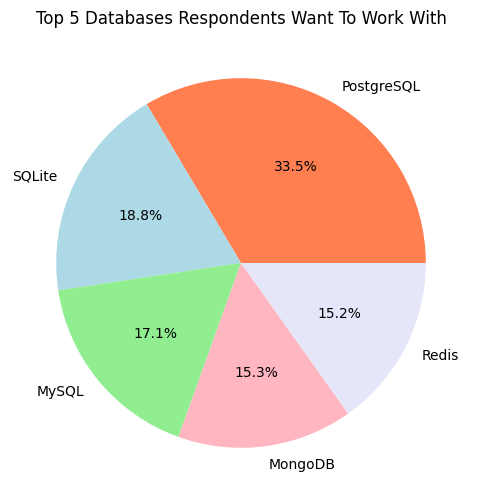

In [7]:
##Write your code here
plt.figure(figsize=(14,6))
db['Count'].plot(kind='pie', labels=db['DatabaseWantToWorkWith'],
                 autopct='%1.1f%%',
                 colors=['coral', 'lightblue', 'lightgreen', 'lightpink', 'lavender']
                )
plt.title('Top 5 Databases Respondents Want To Work With')

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



Text(0.5, 1.0, 'Top 5 Developer Roles')

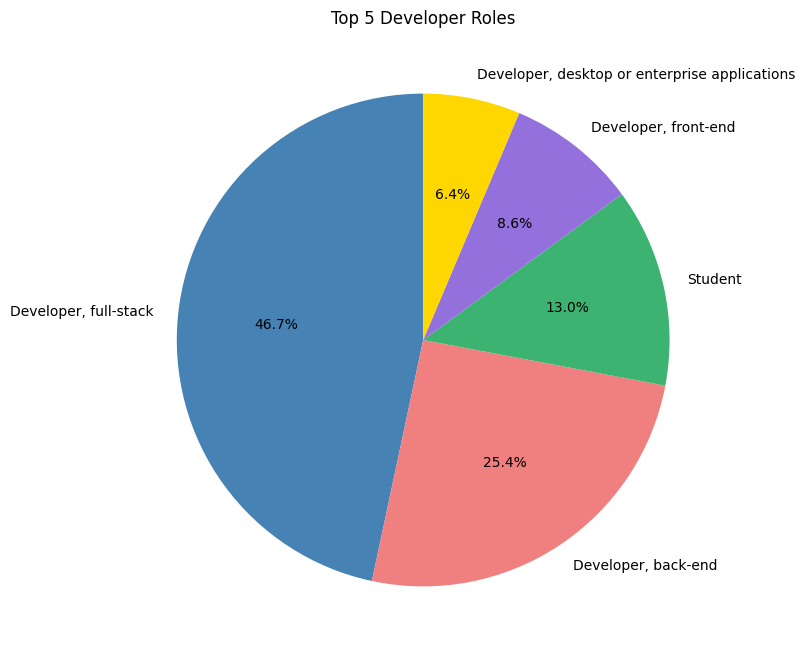

In [8]:
##Write your code here
plt.figure(figsize=(16,8))
df['DevType'].value_counts().head().plot(kind='pie',
                                         autopct='%1.1f%%',
                                        colors=['steelblue','lightcoral','mediumseagreen','mediumpurple','gold'],
                                        startangle=90)
plt.title("Top 5 Developer Roles")

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



In [9]:
##Write your code here
os=df[['OpSysProfessional use']].copy()
os['OpSysProfessional use']=df['OpSysProfessional use'].str.split(';')
os=os.explode('OpSysProfessional use').reset_index(drop=True)

Text(0.5, 1.0, 'Top 5 Operating Systems Developers Use')

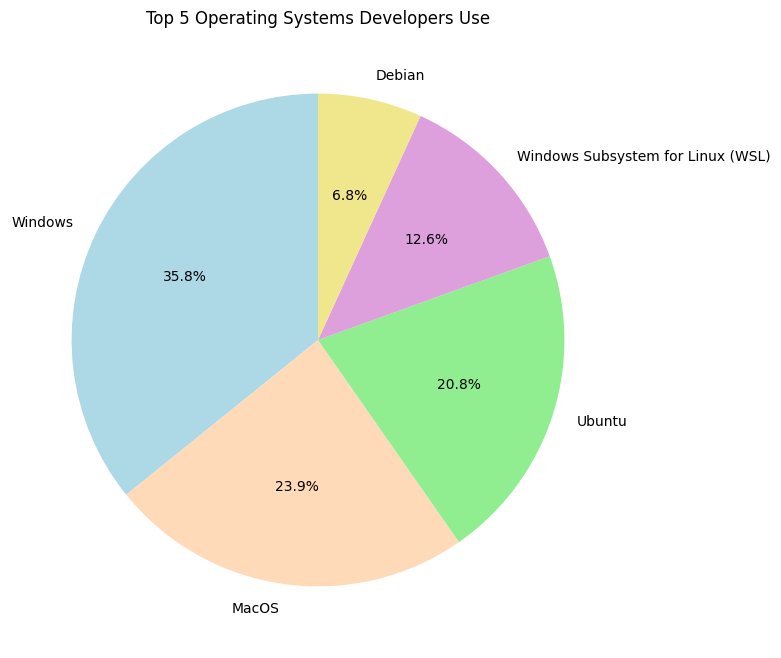

In [10]:
plt.figure(figsize=(16,8))
os['OpSysProfessional use'].value_counts().head().plot(kind='pie',
                                                       autopct='%1.1f%%',
                                                       colors=['lightblue', 'peachpuff', 'lightgreen', 'plum', 'khaki'],
                                                       startangle=90)
plt.title('Top 5 Operating Systems Developers Use')

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



In [11]:
##Write your code here
lg=df[['LanguageHaveWorkedWith']].copy()
lg['LanguageHaveWorkedWith']=lg['LanguageHaveWorkedWith'].str.split(';')
lg=lg.explode('LanguageHaveWorkedWith').reset_index(drop=True)

In [20]:
lg['LanguageHaveWorkedWith'].value_counts().head(10).index

Index(['JavaScript', 'HTML/CSS', 'Python', 'SQL', 'TypeScript',
       'Bash/Shell (all shells)', 'Java', 'C#', 'C++', 'C'],
      dtype='str', name='LanguageHaveWorkedWith')

Text(0.5, 1.0, 'Top 10 Programming Languages Respondents Want To Work With')

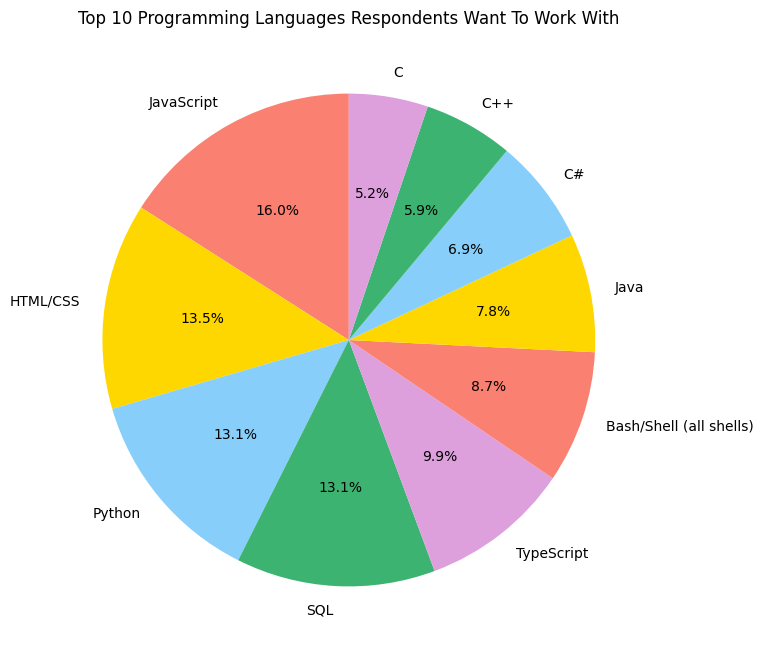

In [12]:
plt.figure(figsize=(16,8))
lg['LanguageHaveWorkedWith'].value_counts().head(10).plot(kind='pie',
                                                        autopct='%1.1f%%',
                                                        colors=['salmon', 'gold', 'lightskyblue', 'mediumseagreen', 'plum'],
                                                        startangle=90)
plt.title('Top 10 Programming Languages Respondents Want To Work With')

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



In [13]:
##Write your code here
co=df[['NEWCollabToolsHaveWorkedWith']].copy()
co['NEWCollabToolsHaveWorkedWith']=co['NEWCollabToolsHaveWorkedWith'].str.split(';')
co=co.explode('NEWCollabToolsHaveWorkedWith').reset_index(drop=True)

Text(0.5, 1.0, 'Top 5 Collaboration Tools used in Proffesional Use')

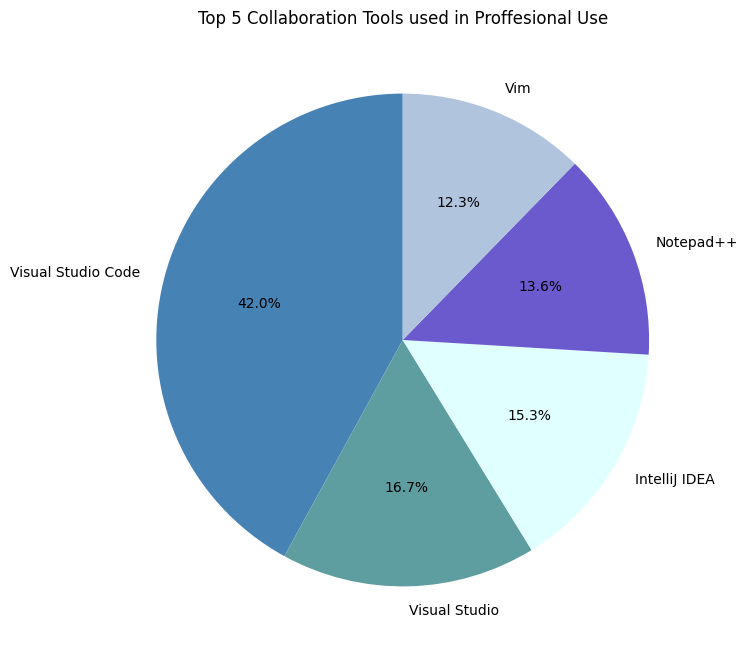

In [14]:
plt.figure(figsize=(16,8))
df['NEWCollabToolsHaveWorkedWith'].str.split(';').explode().reset_index(drop=True).value_counts().head().plot(kind='pie',
                                                                                                              autopct='%1.1f%%',
                                                                                                              colors=['steelblue', 'cadetblue', 'lightcyan', 'slateblue', 'lightsteelblue'],
                                                                                                              startangle=90)
plt.title('Top 5 Collaboration Tools used in Proffesional Use')

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



Text(0.5, 1.0, 'Top 5 Admired Programming Languages')

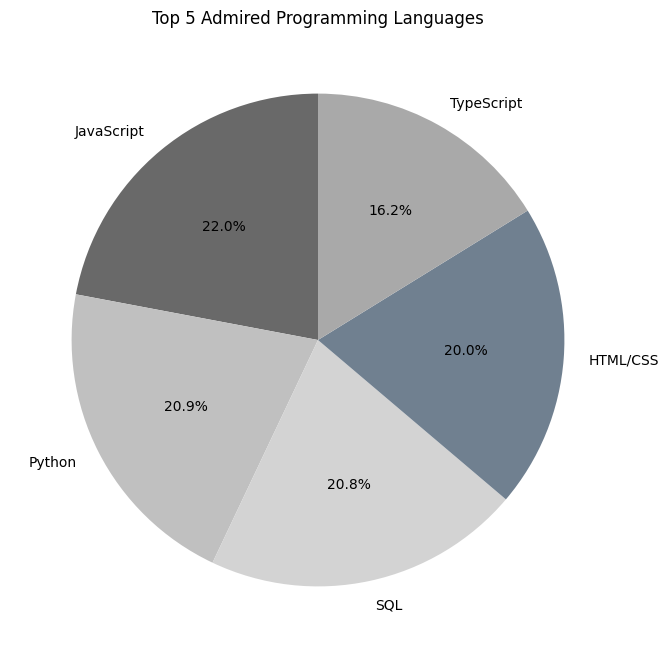

In [15]:
##Write your code here
plt.figure(figsize=(16,8))
df['LanguageAdmired'].str.split(';').explode().reset_index(drop=True).value_counts().head().plot(kind='pie',
                                                                                                 colors=['dimgray', 'silver', 'lightgray', 'slategray', 'darkgray'],
                                                                                                 autopct='%1.1f%%',
                                                                                                 startangle=90)
plt.title('Top 5 Admired Programming Languages')

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



Text(0.5, 1.0, 'Top 5 Tools Used for AI Development')

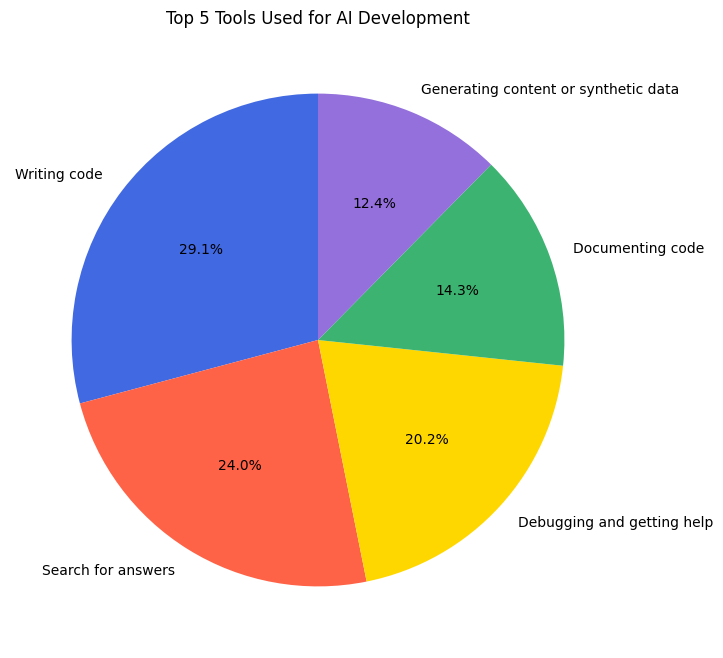

In [16]:
##Write your code here
plt.figure(figsize=(16,8))
df['AIToolCurrently Using'].str.split(';')\
.explode().reset_index(drop=True)\
.value_counts().head().plot(kind='pie',
                            autopct='%1.1f%%',
                            startangle=90,
                            colors=['royalblue', 'tomato', 'gold', 'mediumseagreen', 'mediumpurple'],)
plt.title('Top 5 Tools Used for AI Development')

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



Text(0.5, 1.0, 'Top 5 Preffered Web Frameworks')

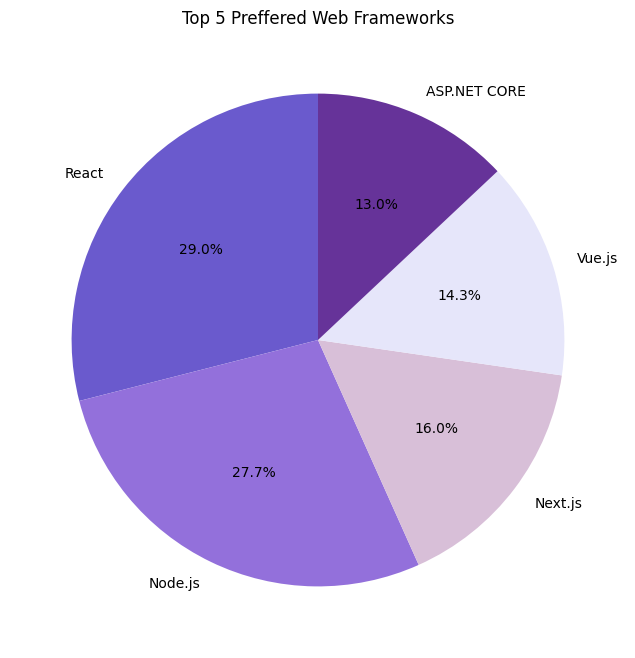

In [17]:
##Write your code here
plt.figure(figsize=(16,8))
df['WebframeWantToWorkWith'].str.split(';')\
.explode().reset_index(drop=True)\
.value_counts().head().plot(kind='pie',
                            autopct='%1.1f%%',
                            colors=['slateblue', 'mediumpurple', 'thistle', 'lavender', 'rebeccapurple'],
                            startangle=90)
plt.title('Top 5 Preffered Web Frameworks')

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



Text(0.5, 1.0, 'Top 5 Desired Embedded Technologies')

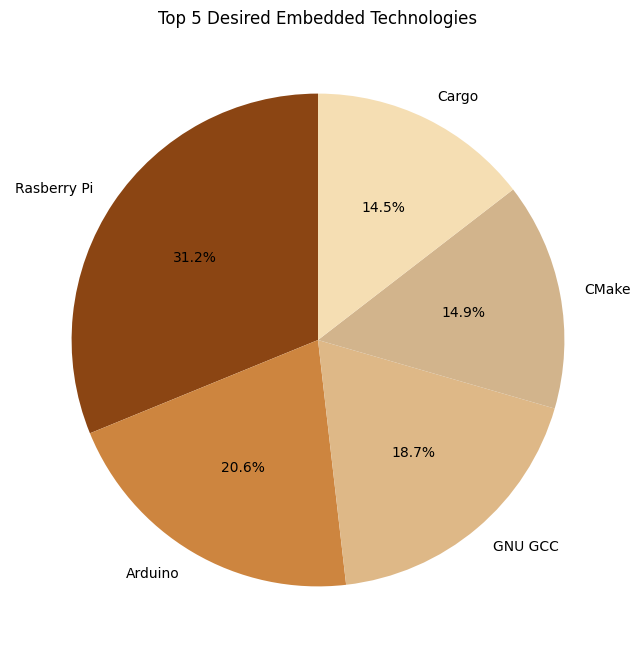

In [18]:
##Write your code here
plt.figure(figsize=(16,8))
df['EmbeddedWantToWorkWith'].str.split(';')\
.explode().reset_index(drop=True)\
.value_counts().head().plot(kind='pie',
                             autopct='%1.1f%%',
                             colors=['saddlebrown', 'peru', 'burlywood', 'tan', 'wheat'],
                             startangle=90)
plt.title('Top 5 Desired Embedded Technologies')

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
